import

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score
)
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

preprocess

In [20]:
#revised 4

df = pd.read_csv('heart_attack_prediction_indonesia.csv')

columns_to_drop = [
    'alcohol_consumption', 'blood_pressure_diastolic', 'triglycerides',
    'physical_activity', 'air_pollution_exposure', 'participated_in_free_screening',
    'EKG_results', 'sleep_hours', 'stress_level',
    'dietary_habits', 'income_level', 'region_Urban', 'region', 'gender'
]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)

smoking_map = {
    'Never': 0,
    'Past': 2,       
    'Current': 3
}
df['smoking_status'] = df['smoking_status'].map(smoking_map)
if df['smoking_status'].isnull().any():
    df['smoking_status'] = df['smoking_status'].fillna(0)
df['smoking_status'] = df['smoking_status'].astype(int)

neg_ldl_count = (df['cholesterol_ldl'] < 0).sum()
if neg_ldl_count > 0:
    df = df[df['cholesterol_ldl'] > 0].copy()

if 'cholesterol_level' in df.columns:
    print("check work")
else:
    print("nothing")

df['ldl_hdl_ratio'] = df['cholesterol_ldl'] / df['cholesterol_hdl']
df['metabolic_syndrome'] = (
    (df['diabetes'] == 1) & 
    (df['hypertension'] == 1) & 
    (df['obesity'] == 1)
).astype(int)
df['bp_hypertension'] = df['blood_pressure_systolic'] * df['hypertension']
df['age_previous_hd'] = df['age'] * df['previous_heart_disease']
df['age_smoking'] = df['age'] * df['smoking_status']
df['ldl_with_diabetes'] = df['cholesterol_ldl'] * df['diabetes']

#check
display(df.info())

check work
<class 'pandas.DataFrame'>
Index: 158335 entries, 0 to 158354
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      158335 non-null  int64  
 1   hypertension             158335 non-null  int64  
 2   diabetes                 158335 non-null  int64  
 3   cholesterol_level        158335 non-null  int64  
 4   obesity                  158335 non-null  int64  
 5   waist_circumference      158335 non-null  int64  
 6   family_history           158335 non-null  int64  
 7   smoking_status           158335 non-null  int64  
 8   blood_pressure_systolic  158335 non-null  int64  
 9   fasting_blood_sugar      158335 non-null  int64  
 10  cholesterol_hdl          158335 non-null  int64  
 11  cholesterol_ldl          158335 non-null  int64  
 12  previous_heart_disease   158335 non-null  int64  
 13  medication_usage         158335 non-null  int64  
 14  heart_att

None

split

In [ ]:
# Identify categorical features (smoking_status is now numeric, so it won't be one-hot encoded)
categorical_features = df.select_dtypes(include=['object']).columns

# Split X and y
X = df.drop('heart_attack', axis=1)
y = df['heart_attack']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# one hot encode
x_train_processed = pd.get_dummies(x_train, columns=categorical_features, drop_first=True)
x_test_processed = pd.get_dummies(x_test, columns=categorical_features, drop_first=True)

# making sure get same columns in train and test
x_test_processed = x_test_processed.reindex(columns=x_train_processed.columns, fill_value=0)

# MinMaxScaler
minmax_scaler = MinMaxScaler()
x_train_minmax_scaled = minmax_scaler.fit_transform(x_train_processed)
x_test_minmax_scaled = minmax_scaler.transform(x_test_processed)

print(f"Training data shape: {x_train_minmax_scaled.shape}")
print(f"Testing data shape: {x_test_minmax_scaled.shape}")

Training data shape: (126668, 20)
Testing data shape: (31667, 20)


models

random forest

In [22]:
# Random Forest with GridSearch
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [15, 20],
    'min_samples_leaf': [8]
}
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search_rf = GridSearchCV(
    estimator=rf_model, param_grid=param_grid_rf,
    cv=2, n_jobs=-1, verbose=2, scoring='accuracy'
)
grid_search_rf.fit(x_train_minmax_scaled, y_train)

best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(x_test_minmax_scaled)

print(f"Best RF Parameters: {grid_search_rf.best_params_}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_best_rf))

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best RF Parameters: {'max_depth': 20, 'min_samples_leaf': 8, 'n_estimators': 100}

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.80      0.74      0.77     18968
           1       0.65      0.72      0.68     12699

    accuracy                           0.73     31667
   macro avg       0.72      0.73      0.72     31667
weighted avg       0.74      0.73      0.73     31667



linear svc

In [23]:
# Linear SVC with GridSearch
param_grid_svc = {
    'C': [20, 50, 100],
    'max_iter': [3000, 5000, 8000],
    'tol': [1e-4, 1e-3],
    'class_weight': [None, 'balanced']
}
svc_model = LinearSVC(random_state=42, dual=False)

grid_search_svc = GridSearchCV(
    estimator=svc_model, param_grid=param_grid_svc,
    cv=3, n_jobs=-1, verbose=2, scoring='f1'
)
grid_search_svc.fit(x_train_minmax_scaled, y_train)

best_svc_model = grid_search_svc.best_estimator_
y_pred_best_svc = best_svc_model.predict(x_test_minmax_scaled)

print(f"Best SVC Parameters: {grid_search_svc.best_params_}")
print("\nClassification Report (Linear SVC):")
print(classification_report(y_test, y_pred_best_svc))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best SVC Parameters: {'C': 20, 'class_weight': 'balanced', 'max_iter': 3000, 'tol': 0.001}

Classification Report (Linear SVC):
              precision    recall  f1-score   support

           0       0.78      0.73      0.76     18968
           1       0.63      0.69      0.66     12699

    accuracy                           0.72     31667
   macro avg       0.71      0.71      0.71     31667
weighted avg       0.72      0.72      0.72     31667



xgboost

scale_pos_weight: 1.49
[0]	validation_0-logloss:0.68239
[50]	validation_0-logloss:0.53453
[100]	validation_0-logloss:0.51564
[150]	validation_0-logloss:0.51202
[200]	validation_0-logloss:0.51118
[250]	validation_0-logloss:0.51130
[300]	validation_0-logloss:0.51132
[350]	validation_0-logloss:0.51145
[400]	validation_0-logloss:0.51149
[450]	validation_0-logloss:0.51162
[499]	validation_0-logloss:0.51175
Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.81      0.71      0.76     18968
           1       0.64      0.75      0.69     12699

    accuracy                           0.73     31667
   macro avg       0.72      0.73      0.72     31667
weighted avg       0.74      0.73      0.73     31667

ROC-AUC: 0.8182


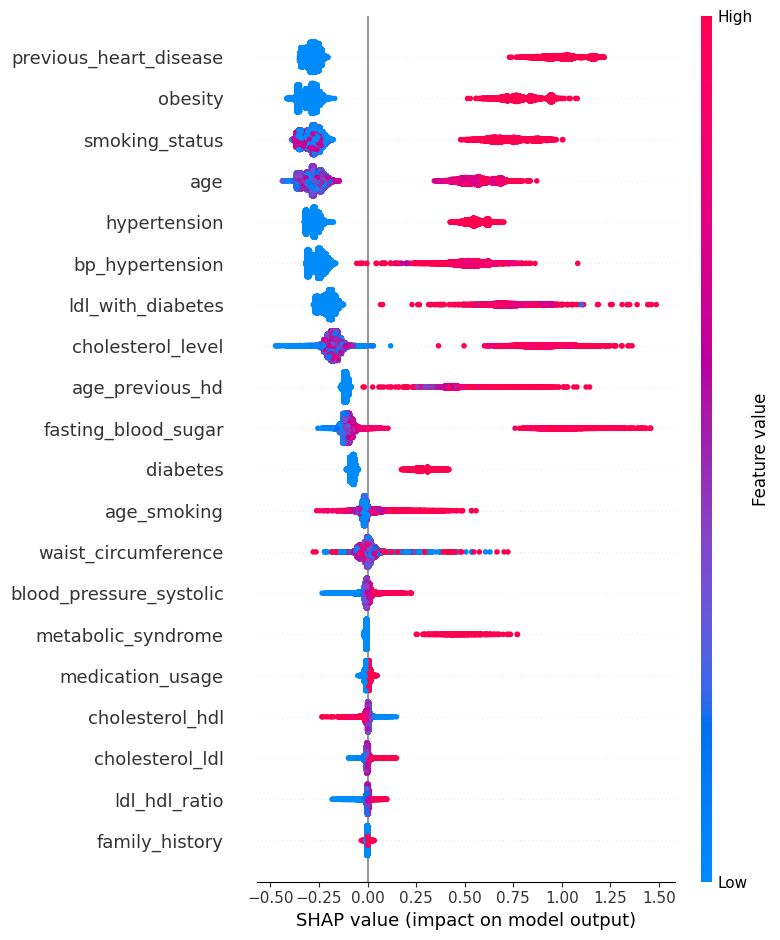

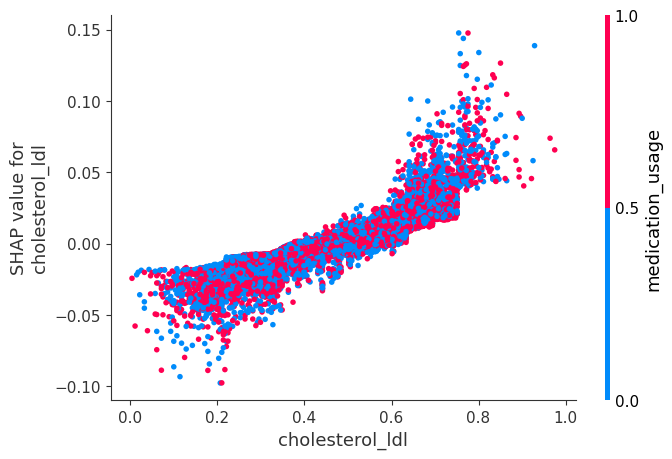

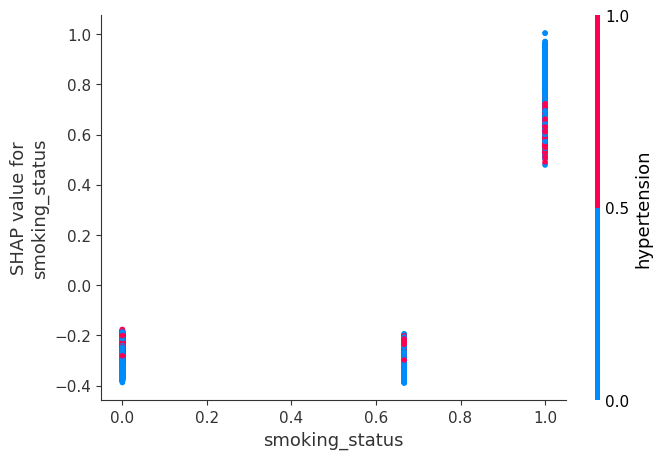

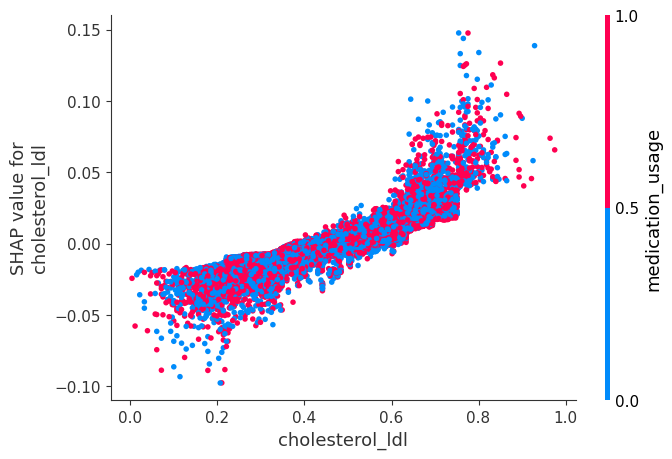

XGB ROC-AUC: 0.8182


In [ ]:
# xgboost

# imbalance handle
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {pos_weight:.2f}")

feature_names = x_train_processed.columns.tolist()

#civtionary constraint
constraint_dict = {
    'cholesterol_ldl': 1,       #increase risk
    'cholesterol_hdl': -1,      #decrease risk
    'ldl_hdl_ratio': 1,         #overall increase risk
    'age': 1,                   #increase risk
    'blood_pressure_systolic': 1,
    'fasting_blood_sugar': 1,
}

x_train_scaled_df = pd.DataFrame(x_train_minmax_scaled, columns=feature_names)
x_test_scaled_df = pd.DataFrame(x_test_minmax_scaled, columns=feature_names)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.3,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=3.0,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss',
    monotone_constraints=constraint_dict
)

xgb_model.fit(
    x_train_scaled_df, y_train,
    eval_set=[(x_test_scaled_df, y_test)],
    verbose=50
)

y_pred_xgb = xgb_model.predict(x_test_scaled_df)
y_probs_xgb = xgb_model.predict_proba(x_test_scaled_df)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs_xgb):.4f}")

#visualization
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test_scaled_df)
shap.summary_plot(shap_values, x_test_scaled_df)
shap.dependence_plot(
    'cholesterol_ldl', shap_values, x_test_scaled_df,
    interaction_index='medication_usage'
)
shap.dependence_plot('smoking_status', shap_values, x_test_scaled_df)
shap.dependence_plot(
    'cholesterol_ldl', shap_values, x_test_scaled_df,
    interaction_index='medication_usage'
)



#save pkl
import pickle

# Compute ROC AUC score for XGBoost
xgb_auc = roc_auc_score(y_test, y_probs_xgb)

roc_auc_results = {
    'roc_auc': xgb_auc,
    'model': xgb_model,
    'scaler': minmax_scaler,
    'feature_columns': feature_names
}

with open('roc_auc_results.pkl', 'wb') as f:
    pickle.dump(roc_auc_results, f)

print(f"XGB ROC-AUC: {xgb_auc:.4f}")

catboost and thresold also auc

In [25]:
# CatBoost Classifier
catboost_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    loss_function='Logloss', eval_metric='AUC',
    auto_class_weights='Balanced', random_seed=42, verbose=100
)
catboost_model.fit(x_train_minmax_scaled, y_train)
y_probs_cat = catboost_model.predict_proba(x_test_minmax_scaled)[:, 1]

# Threshold Tuning for CatBoost
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_cat)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 0.0001)
best_threshold_cat = thresholds[np.argmax(f1_scores)]
best_f1_cat = np.max(f1_scores)

y_pred_cat_adjusted = (y_probs_cat > best_threshold_cat).astype(int)

print(f"Best CatBoost Threshold: {best_threshold_cat:.4f}")
print(f"Best CatBoost F1 Score: {best_f1_cat:.4f}")
print("\nClassification Report (CatBoost - Optimized Threshold):")
print(classification_report(y_test, y_pred_cat_adjusted))

print(f"\nROC-AUC Score (CatBoost): {roc_auc_score(y_test, y_probs_cat):.4f}")

0:	total: 7.29ms	remaining: 3.64s
100:	total: 583ms	remaining: 2.3s
200:	total: 1.15s	remaining: 1.72s
300:	total: 1.7s	remaining: 1.13s
400:	total: 2.25s	remaining: 557ms
499:	total: 2.8s	remaining: 0us
Best CatBoost Threshold: 0.4444
Best CatBoost F1 Score: 0.6927

Classification Report (CatBoost - Optimized Threshold):
              precision    recall  f1-score   support

           0       0.83      0.65      0.73     18968
           1       0.61      0.81      0.69     12699

    accuracy                           0.71     31667
   macro avg       0.72      0.73      0.71     31667
weighted avg       0.74      0.71      0.71     31667


ROC-AUC Score (CatBoost): 0.8185


voting clasifier

In [26]:
# Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('xgb', xgb_model),
        ('cat', catboost_model)
    ],
    voting='soft'
)
voting_clf.fit(x_train_scaled_df, y_train)

y_probs_ensemble = voting_clf.predict_proba(x_test_scaled_df)[:, 1]

# Threshold Tuning for Ensemble
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_ensemble)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 0.0001)
best_threshold_ens = thresholds[np.argmax(f1_scores)]

y_pred_ensemble = (y_probs_ensemble > best_threshold_ens).astype(int)

print(f"Best Ensemble Threshold: {best_threshold_ens:.4f}")
print("\nClassification Report (Voting Ensemble):")
print(classification_report(y_test, y_pred_ensemble))

0:	total: 6.71ms	remaining: 3.35s
100:	total: 610ms	remaining: 2.41s
200:	total: 1.18s	remaining: 1.75s
300:	total: 1.74s	remaining: 1.15s
400:	total: 2.31s	remaining: 570ms
499:	total: 2.87s	remaining: 0us
Best Ensemble Threshold: 0.4340

Classification Report (Voting Ensemble):
              precision    recall  f1-score   support

           0       0.84      0.64      0.73     18968
           1       0.60      0.81      0.69     12699

    accuracy                           0.71     31667
   macro avg       0.72      0.73      0.71     31667
weighted avg       0.74      0.71      0.71     31667



deep learning

build and train

In [27]:
dl_model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train_minmax_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = dl_model.fit(
    x_train_minmax_scaled, y_train,
    validation_split=0.2,
    epochs=50, batch_size=128, verbose=1
)

Epoch 1/50


c:\Users\tshin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7140 - loss: 0.5485 - val_accuracy: 0.7256 - val_loss: 0.5288
Epoch 2/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.7233 - loss: 0.5285 - val_accuracy: 0.7246 - val_loss: 0.5216
Epoch 3/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.7267 - loss: 0.5235 - val_accuracy: 0.7271 - val_loss: 0.5189
Epoch 4/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 958us/step - accuracy: 0.7265 - loss: 0.5192 - val_accuracy: 0.7292 - val_loss: 0.5117
Epoch 5/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 951us/step - accuracy: 0.7284 - loss: 0.5163 - val_accuracy: 0.7307 - val_loss: 0.5098
Epoch 6/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.7288 - loss: 0.5146 - val_accuracy: 0.7285 - val_loss: 0.5128
Epoch 7/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - accuracy: 0.7273 - loss: 0.5140 - val_accuracy: 0.7298 - val_loss: 0.5094
Epoch 8/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.7297 - loss: 0.5122 - val_accuracy:

evaluate

In [28]:
# Deep Learning Predictions
y_probs_dl = dl_model.predict(x_test_minmax_scaled)
y_pred_dl = (y_probs_dl > 0.5).astype(int)

print("Classification Report (Deep Learning - Threshold 0.5):")
print(classification_report(y_test, y_pred_dl))

# Threshold Tuning for DL
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_dl)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 0.0001)
best_threshold_dl = thresholds[np.argmax(f1_scores)]

y_pred_dl_adjusted = (y_probs_dl > best_threshold_dl).astype(int)

print(f"\nBest DL Threshold: {best_threshold_dl:.4f}")
print(classification_report(y_test, y_pred_dl_adjusted))

print(f"\nDeep Learning ROC-AUC Score: {roc_auc_score(y_test, y_probs_dl):.4f}")

990/990 ━━━━━━━━━━━━━━━━━━━━ 0s 270us/step
Classification Report (Deep Learning - Threshold 0.5):
              precision    recall  f1-score   support

           0       0.77      0.80      0.78     18968
           1       0.68      0.64      0.66     12699

    accuracy                           0.74     31667
   macro avg       0.73      0.72      0.72     31667
weighted avg       0.73      0.74      0.73     31667


Best DL Threshold: 0.3535
              precision    recall  f1-score   support

           0       0.85      0.60      0.70     18968
           1       0.58      0.84      0.69     12699

    accuracy                           0.69     31667
   macro avg       0.71      0.72      0.69     31667
weighted avg       0.74      0.69      0.69     31667


Deep Learning ROC-AUC Score: 0.8128


data visualization

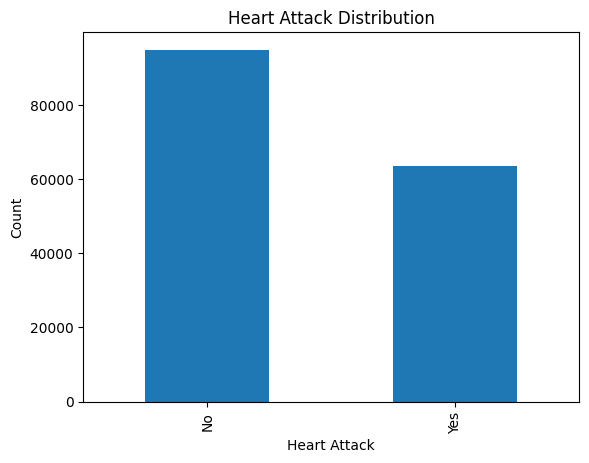

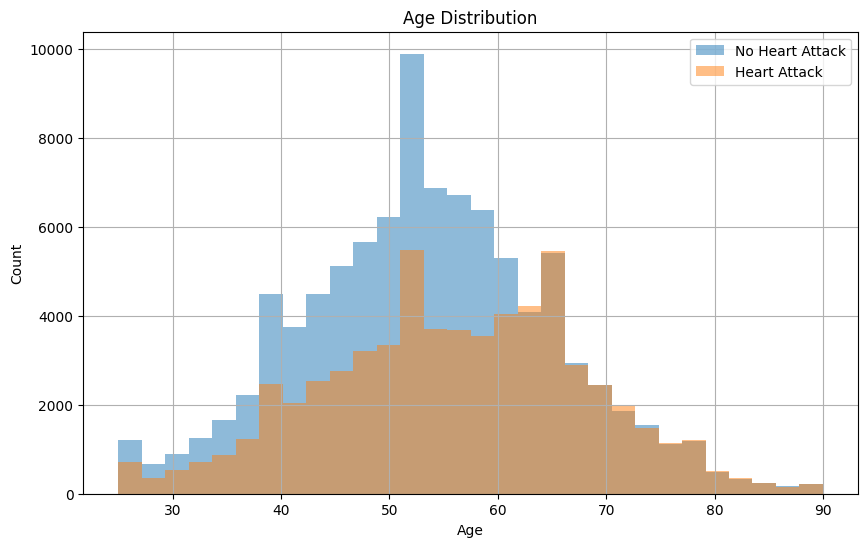

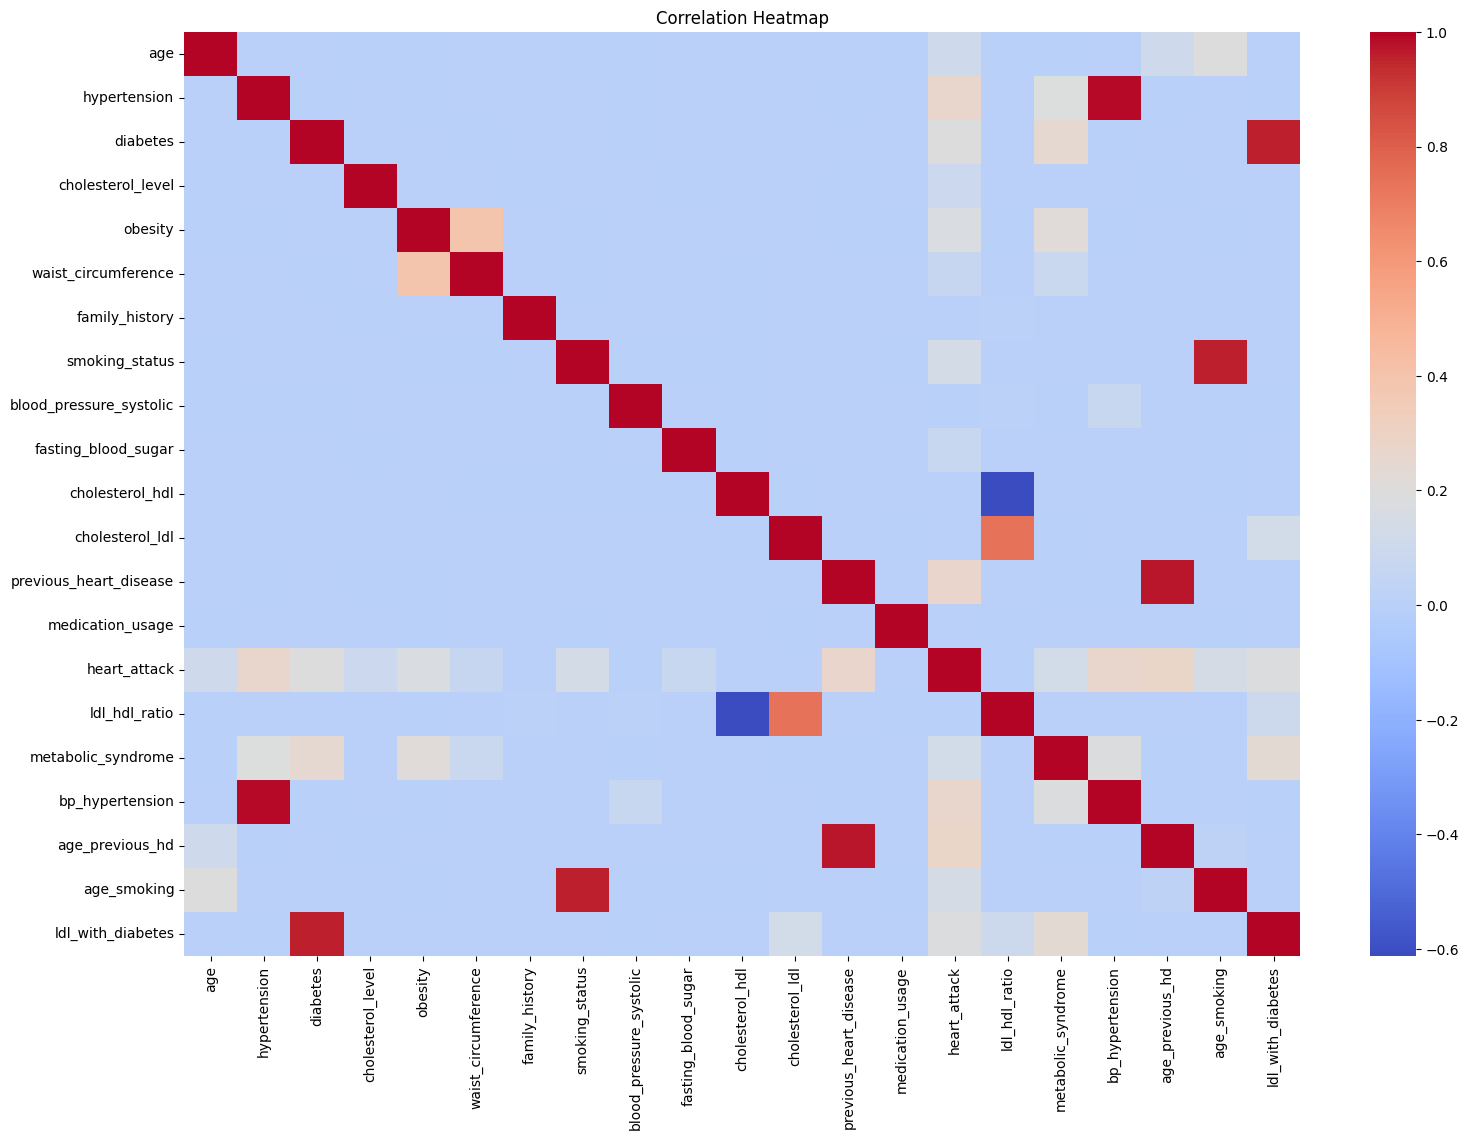

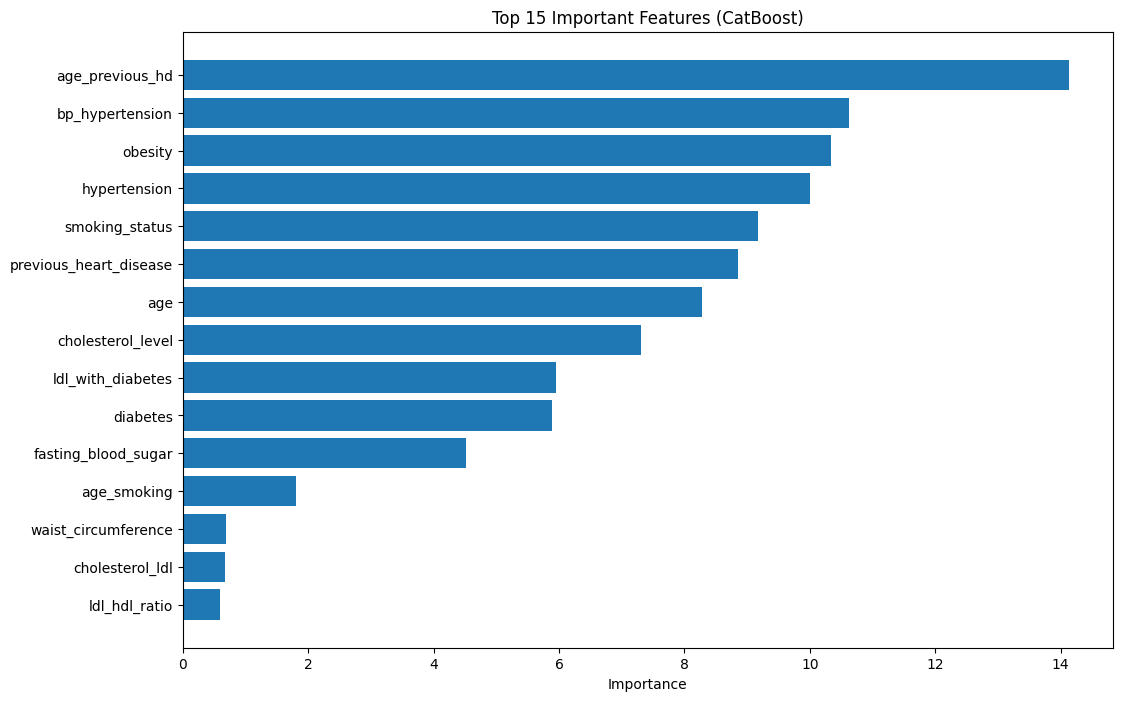

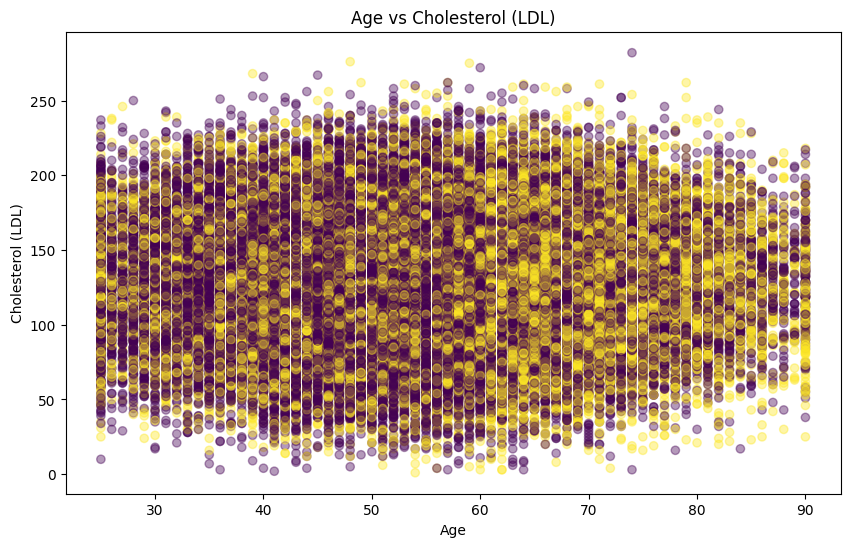

In [29]:
# 1. Target Distribution
df['heart_attack'].value_counts().plot(kind='bar')
plt.title('Heart Attack Distribution')
plt.xlabel('Heart Attack')
plt.ylabel('Count')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

# 2. Age Distribution by Target
plt.figure(figsize=(10,6))
df[df['heart_attack'] == 0]['age'].hist(alpha=0.5, bins=30, label='No Heart Attack')
df[df['heart_attack'] == 1]['age'].hist(alpha=0.5, bins=30, label='Heart Attack')
plt.legend()
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(18,12))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

# 4. Feature Importance (CatBoost)
feature_importance = pd.DataFrame({
    'Feature': x_train_processed.columns,
    'Importance': catboost_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Important Features (CatBoost)')
plt.xlabel('Importance')
plt.show()

# 5. Age vs Cholesterol Scatter
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['cholesterol_ldl'], c=df['heart_attack'], alpha=0.4)
plt.title('Age vs Cholesterol (LDL)')
plt.xlabel('Age')
plt.ylabel('Cholesterol (LDL)')
plt.show()